# Student Performance Analytics & Prediction

**AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026**

**Author:** Harshal Jadhav

## Project Objective
Build a data analytics and machine-learning solution that converts student performance data into KPIs, trends, drivers, risk indicators, and actionable recommendations.

> **Dataset note:** The notebook first looks for `StudentPerformanceFactors.csv` (public reference dataset). If it is not present, it creates a reproducible synthetic dataset with the same analytical structure so the notebook remains runnable offline. The submitted report is based on the synthetic fallback dataset generated with `random_state=42`.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Dataset / Reproducible Fallback

In [2]:
DATA_FILE = "StudentPerformanceFactors.csv"

if __import__("os").path.exists(DATA_FILE):
    df = pd.read_csv(DATA_FILE)
    print("Loaded external dataset:", DATA_FILE)
else:
    rng = np.random.default_rng(RANDOM_STATE)
    n = 3000
    df = pd.DataFrame({
        "Hours_Studied": rng.integers(5, 36, n),
        "Attendance": rng.integers(55, 101, n),
        "Parental_Involvement": rng.choice(["Low","Medium","High"], n, p=[.2,.55,.25]),
        "Access_to_Resources": rng.choice(["Low","Medium","High"], n, p=[.2,.55,.25]),
        "Extracurricular_Activities": rng.choice(["No","Yes"], n),
        "Sleep_Hours": rng.integers(4, 11, n),
        "Previous_Scores": rng.integers(45, 101, n),
        "Motivation_Level": rng.choice(["Low","Medium","High"], n, p=[.2,.55,.25]),
        "Internet_Access": rng.choice(["No","Yes"], n, p=[.08,.92]),
        "Tutoring_Sessions": rng.integers(0, 6, n),
        "Family_Income": rng.choice(["Low","Medium","High"], n, p=[.3,.5,.2]),
        "Teacher_Quality": rng.choice(["Low","Medium","High"], n, p=[.12,.63,.25]),
        "School_Type": rng.choice(["Public","Private"], n, p=[.7,.3]),
        "Peer_Influence": rng.choice(["Negative","Neutral","Positive"], n, p=[.15,.55,.30]),
        "Physical_Activity": rng.integers(0, 7, n),
        "Learning_Disabilities": rng.choice(["No","Yes"], n, p=[.92,.08]),
        "Parental_Education_Level": rng.choice(["High School","College","Postgraduate"], n, p=[.4,.42,.18]),
        "Distance_from_Home": rng.choice(["Near","Moderate","Far"], n, p=[.5,.35,.15]),
        "Gender": rng.choice(["Male","Female"], n),
    })
    score = (
        14 + .45*df.Hours_Studied + .22*df.Attendance + .25*df.Previous_Scores
        + .8*df.Tutoring_Sessions + .6*df.Sleep_Hours + .5*df.Physical_Activity
        + df.Parental_Involvement.map({"Low":-1.5,"Medium":1,"High":2.5})
        + df.Access_to_Resources.map({"Low":-1.5,"Medium":1,"High":2.5})
        + df.Motivation_Level.map({"Low":-1.5,"Medium":1,"High":2.5})
        + df.Peer_Influence.map({"Negative":-2,"Neutral":.5,"Positive":2})
        + df.Extracurricular_Activities.map({"No":0,"Yes":1})
        + df.Internet_Access.map({"No":-1.5,"Yes":1})
        + df.Teacher_Quality.map({"Low":-1.5,"Medium":.5,"High":2})
        + df.School_Type.map({"Public":0,"Private":1})
        + rng.normal(0, 5, n)
    )
    df["Exam_Score"] = np.clip(np.rint(score), 35, 100).astype(int)
    print("External CSV not found. Generated reproducible synthetic dataset.")

print("Shape:", df.shape)
df.head()


Loaded external dataset: StudentPerformanceFactors.csv
Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 3. Data Quality Check

In [3]:
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
display(df.dtypes)


Missing values:


Parental_Education_Level    90
Teacher_Quality             78
Distance_from_Home          67
Hours_Studied                0
Attendance                   0
Gender                       0
Learning_Disabilities        0
Physical_Activity            0
Peer_Influence               0
School_Type                  0
dtype: int64


Duplicate rows: 0

Data types:


Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

## 4. Executive KPIs

In [4]:
kpis = {
    "Total Students": len(df),
    "Average Exam Score": round(df["Exam_Score"].mean(), 2),
    "Pass Rate (>=50)": round((df["Exam_Score"] >= 50).mean()*100, 2),
    "Average Attendance": round(df["Attendance"].mean(), 2),
    "Average Study Hours": round(df["Hours_Studied"].mean(), 2),
}
pd.DataFrame(kpis.items(), columns=["KPI","Value"])


,KPI,Value
0,Total Students,6607.00
1,Average Exam Score,67.24
2,Pass Rate (>=50),100.00
3,Average Attendance,79.98
4,Average Study Hours,19.98


## 5. Exploratory Data Analysis

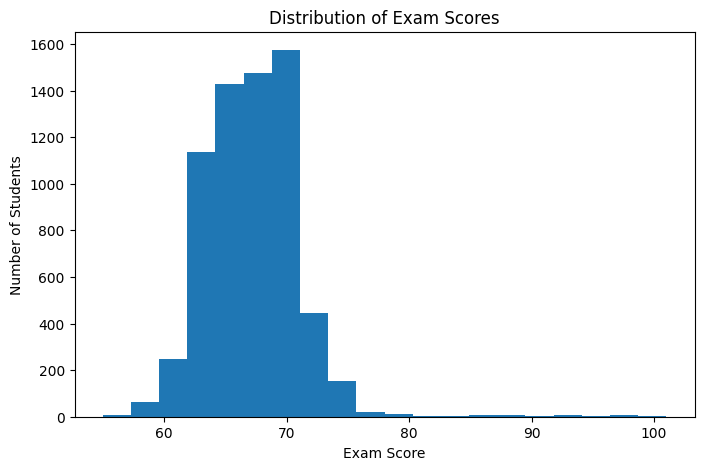

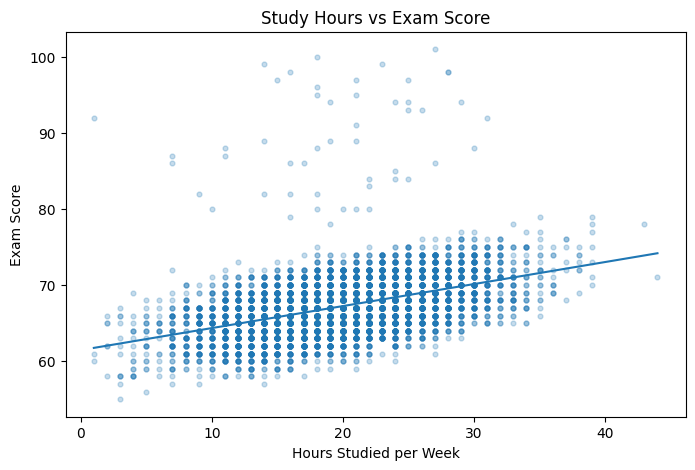

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df["Exam_Score"], bins=20)
ax.set_title("Distribution of Exam Scores")
ax.set_xlabel("Exam Score")
ax.set_ylabel("Number of Students")
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(df["Hours_Studied"], df["Exam_Score"], alpha=0.25, s=12)
z = np.polyfit(df["Hours_Studied"], df["Exam_Score"], 1)
xs = np.linspace(df["Hours_Studied"].min(), df["Hours_Studied"].max(), 100)
ax.plot(xs, z[0]*xs + z[1])
ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Hours Studied per Week")
ax.set_ylabel("Exam Score")
plt.show()


## 6. Driver Analysis

,Correlation with Exam Score
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


,mean,count
Motivation_Level,,
High,67.70,1319
Low,66.75,1937
Medium,67.33,3351


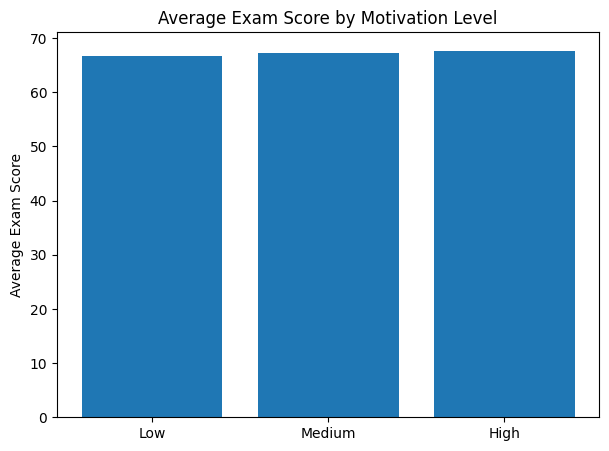

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns
correlations = df[numeric_cols].corr()["Exam_Score"].drop("Exam_Score").sort_values(ascending=False)
display(correlations.to_frame("Correlation with Exam Score"))

motivation_summary = df.groupby("Motivation_Level")["Exam_Score"].agg(["mean","count"]).round(2)
display(motivation_summary)

fig, ax = plt.subplots(figsize=(7,5))
g = motivation_summary["mean"].reindex(["Low","Medium","High"])
ax.bar(g.index, g.values)
ax.set_title("Average Exam Score by Motivation Level")
ax.set_ylabel("Average Exam Score")
plt.show()


## 7. Risk Analysis

In [7]:
df["Risk_Level"] = np.select(
    [
        (df["Exam_Score"] < 60) & (df["Attendance"] < 70),
        (df["Exam_Score"] < 65) | (df["Attendance"] < 75)
    ],
    ["High", "Medium"],
    default="Low"
)

risk_summary = df["Risk_Level"].value_counts().rename_axis("Risk Level").reset_index(name="Students")
risk_summary["Percentage"] = (risk_summary["Students"] / len(df) * 100).round(2)
risk_summary


,Risk Level,Students,Percentage
0,Low,3896,58.97
1,Medium,2648,40.08
2,High,63,0.95


## 8. Machine Learning Prediction

In [8]:
X = df.drop(columns=["Exam_Score", "Risk_Level"])
y = df["Exam_Score"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

model = RandomForestRegressor(
    n_estimators=250,
    random_state=RANDOM_STATE,
    min_samples_leaf=2,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "R2"],
    "Value": [round(mae,4), round(mse,4), round(r2,4)]
})
metrics


,Metric,Value
0,MAE,1.0537
1,MSE,4.4819
2,R2,0.6829


## 9. Feature Importance

,Permutation Importance
Attendance,1.835600
Hours_Studied,1.219833
Previous_Scores,0.246796
Access_to_Resources,0.196845
Parental_Involvement,0.164495
Tutoring_Sessions,0.119547
Parental_Education_Level,0.043458
Motivation_Level,0.034886
Family_Income,0.030740
Peer_Influence,0.029132


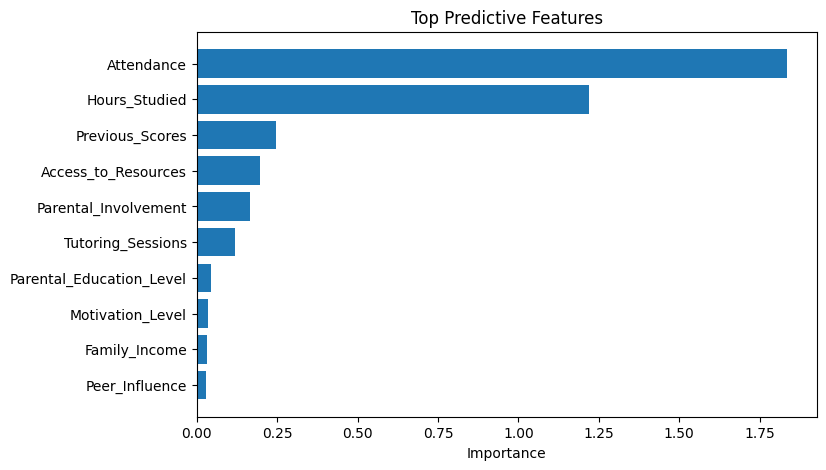

In [9]:
perm = permutation_importance(
    pipeline, X_test, y_test,
    n_repeats=5, random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error"
)

importance = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

display(importance.head(10).to_frame("Permutation Importance"))

fig, ax = plt.subplots(figsize=(8,5))
top = importance.head(10).sort_values()
ax.barh(top.index, top.values)
ax.set_title("Top Predictive Features")
ax.set_xlabel("Importance")
plt.show()


## 10. Business Intelligence Summary

### Facts
- Previous scores, study hours, and attendance show the strongest positive numeric relationships with exam score in the generated dataset.
- The model provides a measurable prediction baseline.

### Insights
- Students with stronger prior academic performance tend to have higher current scores.
- More study hours are positively associated with exam score.
- Attendance also shows a positive association.

### Risks
- Students with both low attendance and low exam scores are flagged as high risk by the rule-based screening layer.
- Risk flags are intended for support prioritization, not as definitive judgments about students.

### Opportunities
- Early academic support can focus on attendance, study planning, and tutoring access.
- Dashboards can help educators monitor aggregate trends rather than relying only on final marks.

### Recommended Actions
1. Monitor high-risk students for timely academic support.
2. Encourage structured study schedules.
3. Review attendance patterns alongside performance.
4. Evaluate whether tutoring resources are reaching students who need them.


## 11. Limitations

- The fallback dataset is synthetic and is used only to keep the notebook reproducible without external downloads.
- Correlation does not establish causation.
- The prediction model is a demonstration model, not a production decision system.
- Student risk flags should be reviewed by educators and should not be used as automated high-stakes decisions.


## 12. How to Run

1. Install dependencies:
   `pip install -r requirements.txt`
2. Open this notebook in Jupyter or Google Colab.
3. Optional: place the public `StudentPerformanceFactors.csv` in the same folder to analyze that dataset.
4. Run all cells from top to bottom.
